<a href="https://colab.research.google.com/github/Ridhafathimaa/global-youtube-statistics-2023/blob/main/youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(995, 28)
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   
1     

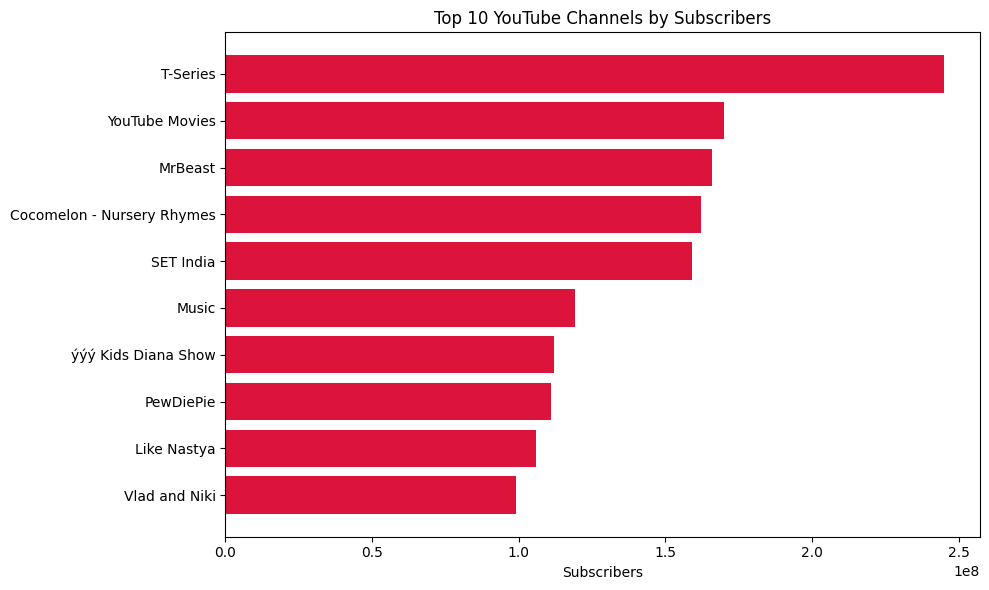

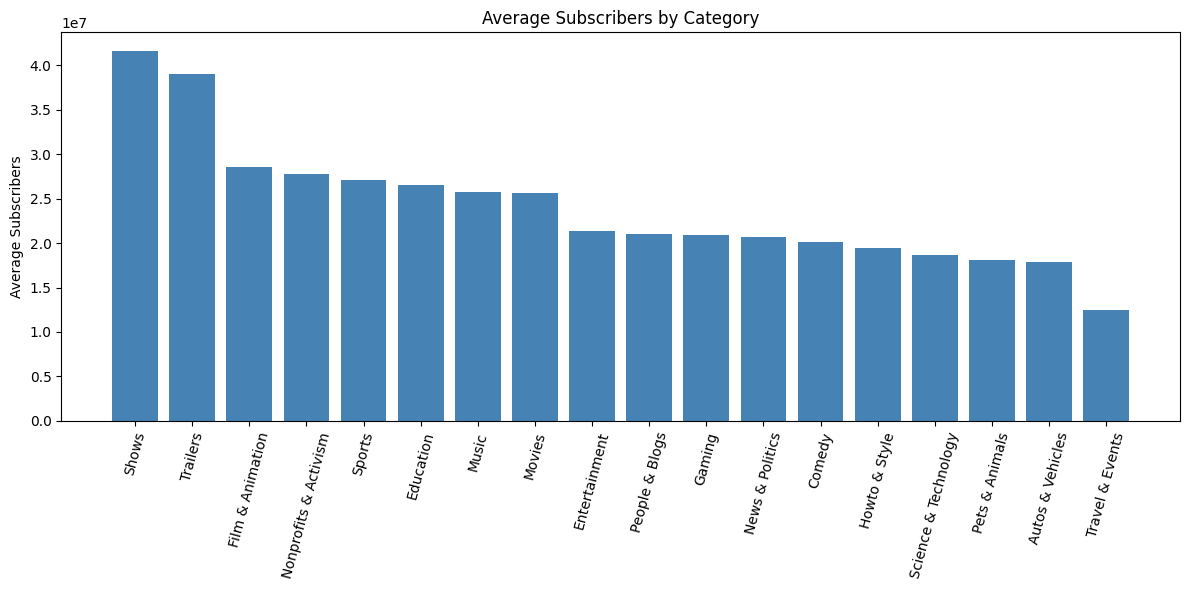

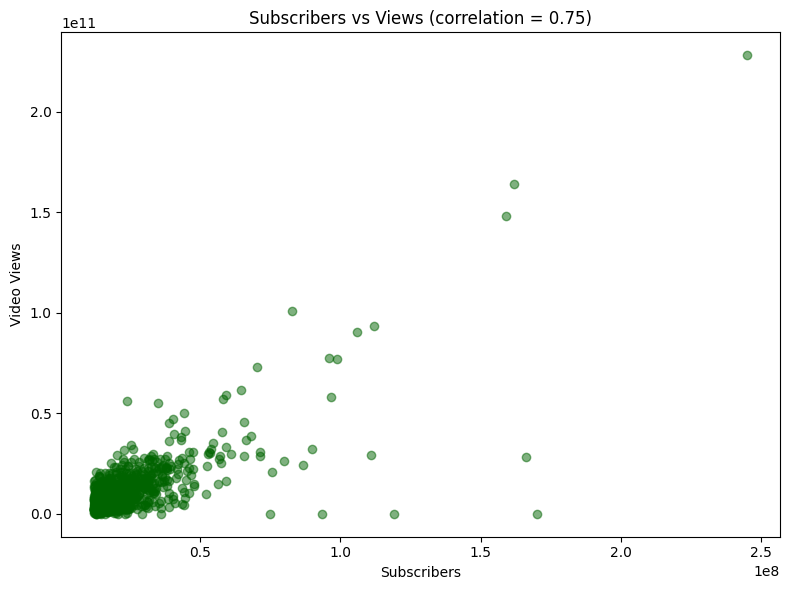

                     youtuber  subscribers          category        country
0                    T-Series    245000000             Music          India
1              YouTube Movies    170000000  Film & Animation  United States
2                     MrBeast    166000000     Entertainment  United States
3  Cocomelon - Nursery Rhymes    162000000         Education  United States
4                   SET India    159000000             Shows          India
5                       Music    119000000               NaN            NaN
6         ýýý Kids Diana Show    112000000    People & Blogs  United States
7                   PewDiePie    111000000            Gaming          Japan
8                 Like Nastya    106000000    People & Blogs         Russia
9               Vlad and Niki     98900000     Entertainment  United States


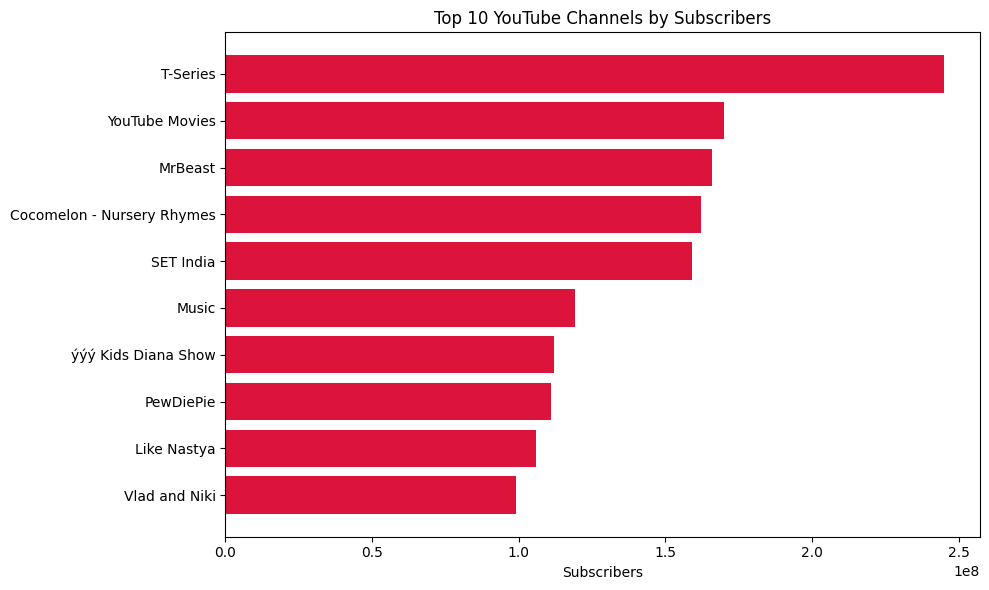

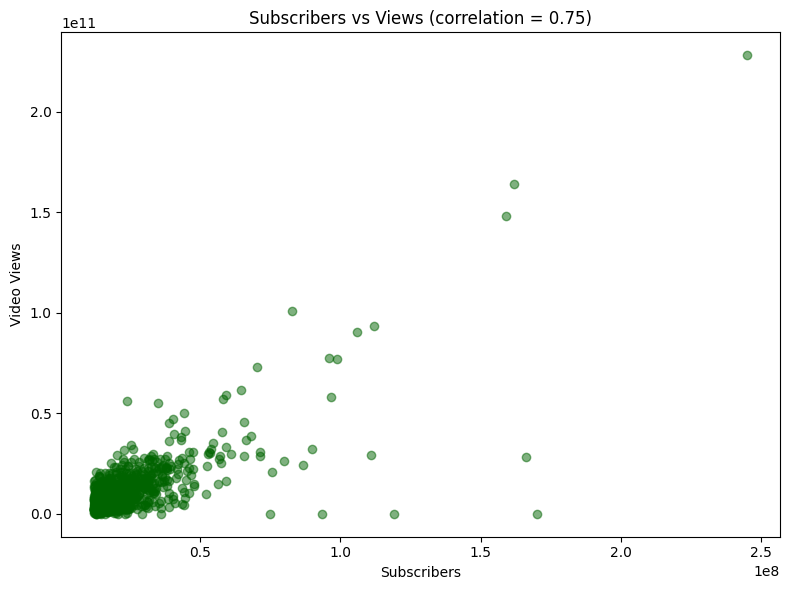

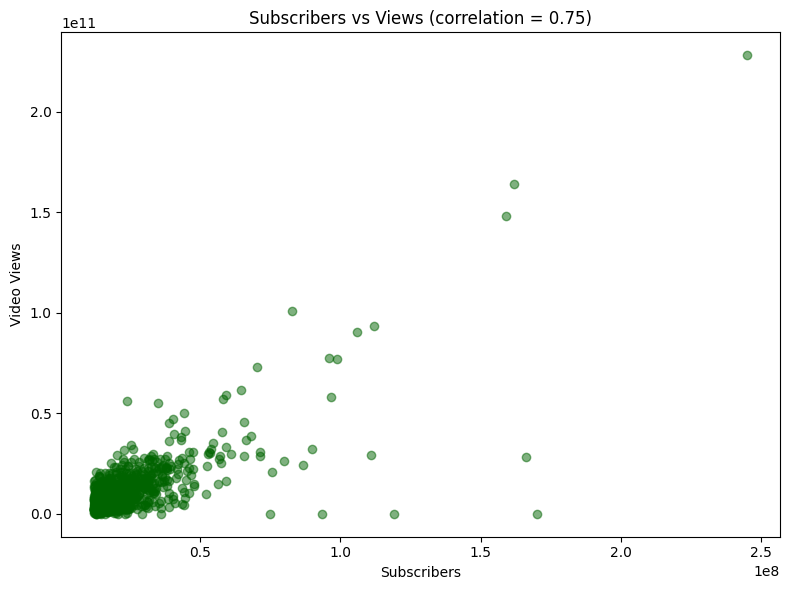

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("Global YouTube Statistics.csv", encoding="latin1")

print(df.shape)
print(df.head())

print("Original column names:")
print(df.columns.tolist())

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[^a-z0-9_]", "", regex=True)
)

print("Cleaned column names:")
print(df.columns.tolist())
df.isnull().sum().sort_values(ascending=False)
# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Fill NaNs with median for each numeric column
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values left in numeric columns
df[numeric_cols].isnull().sum()
df.isnull().sum()
top10_subs = df.sort_values('subscribers', ascending=False).head(10)
top10_subs[['youtuber', 'subscribers', 'category', 'country']]
category_avg = df.groupby('category')[['subscribers', 'video_views']].mean().sort_values('subscribers', ascending=False)
category_avg
df['avg_yearly_earnings'] = (df['lowest_yearly_earnings'] + df['highest_yearly_earnings']) / 2

total_earnings = np.sum(df['avg_yearly_earnings'])
average_earnings = np.mean(df['avg_yearly_earnings'])

print(f"Total earnings across all channels: ${total_earnings:,.2f}")
print(f"Average earnings per channel: ${average_earnings:,.2f}")
correlation = df['subscribers'].corr(df['video_views'])
print(f"Correlation between subscribers and views: {correlation:.3f}")
# Step 5: Top 10 channels by subscribers
top10_subs = df.sort_values('subscribers', ascending=False).head(10)
print(top10_subs[['youtuber', 'subscribers', 'category', 'country']])

print("\n" + "="*50 + "\n")

# Step 6: Average subscribers/views by category
category_avg = df.groupby('category')[['subscribers', 'video_views']].mean().sort_values('subscribers', ascending=False)
print(category_avg)
import matplotlib.pyplot as plt

# 1. Horizontal bar chart - Top 10 channels
plt.figure(figsize=(10,6))
plt.barh(top10_subs['youtuber'], top10_subs['subscribers'], color='crimson')
plt.xlabel('Subscribers')
plt.title('Top 10 YouTube Channels by Subscribers')
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()
# 2. Bar chart - Average subscribers by category
plt.figure(figsize=(12,6))
plt.bar(category_avg.index, category_avg['subscribers'], color='steelblue')
plt.xticks(rotation=75)
plt.ylabel('Average Subscribers')
plt.title('Average Subscribers by Category')
plt.tight_layout()
plt.show()
# 3. Scatter plot - Subscribers vs Views
plt.figure(figsize=(8,6))
plt.scatter(df['subscribers'], df['video_views'], alpha=0.5, color='darkgreen')
plt.xlabel('Subscribers')
plt.ylabel('Video Views')
plt.title(f'Subscribers vs Views (correlation = {correlation:.2f})')
plt.tight_layout()
plt.show()
top10_subs = df.sort_values('subscribers', ascending=False).head(10)
print(top10_subs[['youtuber', 'subscribers', 'category', 'country']])
import matplotlib.pyplot as plt

# Visual 1: Horizontal bar chart - Top 10 channels
plt.figure(figsize=(10,6))
plt.barh(top10_subs['youtuber'], top10_subs['subscribers'], color='crimson')
plt.xlabel('Subscribers')
plt.title('Top 10 YouTube Channels by Subscribers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# Visual 3: Scatter plot - Subscribers vs Views
plt.figure(figsize=(8,6))
plt.scatter(df['subscribers'], df['video_views'], alpha=0.5, color='darkgreen')
plt.xlabel('Subscribers')
plt.ylabel('Video Views')
plt.title(f'Subscribers vs Views (correlation = {correlation:.2f})')
plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['subscribers'], df['video_views'], alpha=0.5, color='darkgreen')
plt.xlabel('Subscribers')
plt.ylabel('Video Views')
plt.title(f'Subscribers vs Views (correlation = {correlation:.2f})')
plt.tight_layout()
plt.show()